In [3]:
!pip install yfinance scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

print('pandas  :', pd.__version__)
print('numpy   :', np.__version__)
print('matplotlib:', plt.matplotlib.__version__)
print('seaborn :', sb.__version__)

pandas  : 3.0.1
numpy   : 2.4.2
matplotlib: 3.10.8
seaborn : 0.13.2


In [8]:
import pandas as pd
import numpy as np

# ----------------------------
# 1. LOAD DATA
# ----------------------------
data = pd.read_csv("Nat_Gas.csv")
data.columns = data.columns.str.strip()
data['Dates'] = pd.to_datetime(data['Dates'], format="%m/%d/%y")
data = data.sort_values(by='Dates')

# ----------------------------
# 2. CONVERT TIME TO NUMBERS
# ----------------------------
start_date = data['Dates'].min()
data['t'] = (data['Dates'] - start_date).dt.days

t     = data['t'].values
price = data['Prices'].values

# ----------------------------
# 3. FIT LINEAR TREND
# ----------------------------
a, b = np.polyfit(t, price, 1)
trend = a * t + b

# ----------------------------
# 4. FIT SEASONAL WAVE
# ----------------------------
detrended = price - trend
omega     = 2 * np.pi / 365

X         = np.column_stack([np.sin(omega * t), np.cos(omega * t)])
coef      = np.linalg.lstsq(X, detrended, rcond=None)[0]

A_sin, A_cos = coef
amplitude    = np.sqrt(A_sin**2 + A_cos**2)
phase        = np.arctan2(A_cos, A_sin)

# ----------------------------
# 5. GET PRICE FUNCTION
# ----------------------------
def get_price(date_input):
    date = pd.Timestamp(date_input)
    days = (date - start_date).days
    
    trend_part    = a * days + b
    seasonal_part = amplitude * np.sin(omega * days + phase)
    
    return float(trend_part + seasonal_part)

# ----------------------------
# 6. QUICK TEST
# ----------------------------
print("Summer price (2023-06-30):", round(get_price("2023-06-30"), 2))
print("Winter price (2023-12-31):", round(get_price("2023-12-31"), 2))
print("\nget_price() is ready!")

Summer price (2023-06-30): 10.99
Winter price (2023-12-31): 12.33

get_price() is ready!


In [16]:
import math

def price_contract(injection_dates, withdrawal_dates,
                   injection_rate, withdrawal_rate,
                   max_volume, storage_cost_per_month,
                   injection_withdrawal_cost_rate=0):

    # --- convert to Timestamps and sort ---
    injection_dates  = sorted([pd.Timestamp(d) for d in injection_dates])
    withdrawal_dates = sorted([pd.Timestamp(d) for d in withdrawal_dates])

    # --- combine and sort ALL dates together ---
    all_dates = sorted(set(injection_dates + withdrawal_dates))

    # --- initialise trackers ---
    tank      = 0
    buy_cost  = 0
    cash_in   = 0

    # --- loop through every date in order ---
    for date in all_dates:

        if date in injection_dates:
            if tank + injection_rate <= max_volume:        # tank has space
                tank     += injection_rate
                buy_cost += injection_rate * get_price(date)
                buy_cost += injection_rate * injection_withdrawal_cost_rate  # pump cost
                print(f"Injected on {date.date()} at ${get_price(date):.2f} | Tank: {tank}")
            else:
                print(f"WARNING: Tank full on {date.date()}, skipping injection")

        elif date in withdrawal_dates:
            if tank >= withdrawal_rate:                    # tank has gas
                tank     -= withdrawal_rate
                cash_in  += withdrawal_rate * get_price(date)
                cash_in  -= withdrawal_rate * injection_withdrawal_cost_rate  # pump cost
                print(f"Withdrew  on {date.date()} at ${get_price(date):.2f} | Tank: {tank}")
            else:
                print(f"WARNING: Tank empty on {date.date()}, skipping withdrawal")

    # --- storage cost (precise — based on actual days) ---
    first_injection  = min(injection_dates)
    last_withdrawal  = max(withdrawal_dates)
    months_stored    = math.ceil((last_withdrawal - first_injection).days / 30)
    storage_cost     = months_stored * storage_cost_per_month

    # --- final value ---
    contract_value = cash_in - buy_cost - storage_cost

    print(f"\n{'='*45}")
    print(f"  Injection Cost (inc. pump cost) : ${buy_cost:,.2f}")
    print(f"  Revenue (after pump cost)       : ${cash_in:,.2f}")
    print(f"  Storage Cost ({months_stored} months)         : ${storage_cost:,.2f}")
    print(f"{'='*45}")
    print(f"  CONTRACT VALUE                  : ${contract_value:,.2f}")
    print(f"{'='*45}\n")

    return contract_value

In [21]:
price_contract(
    injection_dates               = ['2023-07-31', '2023-08-31', '2023-09-30'],
    withdrawal_dates              = ['2023-11-30', '2023-12-31', '2024-01-31'],
    injection_rate                = 5000,
    withdrawal_rate               = 5000,
    max_volume                    = 20000,
    storage_cost_per_month        = 1000,
    injection_withdrawal_cost_rate = 0.05
)


Injected on 2023-07-31 at $10.91 | Tank: 5000
Injected on 2023-08-31 at $11.02 | Tank: 10000
Injected on 2023-09-30 at $11.28 | Tank: 15000
Withdrew  on 2023-11-30 at $12.03 | Tank: 10000
Withdrew  on 2023-12-31 at $12.33 | Tank: 5000
Withdrew  on 2024-01-31 at $12.48 | Tank: 0

  Injection Cost (inc. pump cost) : $166,846.74
  Revenue (after pump cost)       : $183,433.75
  Storage Cost (7 months)         : $7,000.00
  CONTRACT VALUE                  : $9,587.02



9587.018190761475

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# Load data
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')
print(df.shape)
print(df.head())

(10000, 8)
   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  


In [27]:
# Compare defaulters vs non-defaulters
print(df.groupby('default')[['income', 'total_debt_outstanding', 'fico_score']].mean())

               income  total_debt_outstanding  fico_score
default                                                  
0        69883.889804             6322.164549  646.938765
1        70726.740140            19270.582961  596.257699


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

# drop customer_id — it's just an ID, not useful for prediction
X = df.drop(columns=['customer_id', 'default'])
y = df['default']

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 8000
Testing samples : 2000


In [29]:
# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# train the model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print('Model trained!')

Model trained!


In [30]:
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC Score:', round(roc_auc_score(y_test, y_pred_prob), 4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score: 1.0


In [31]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})
print(feature_importance.sort_values('coefficient', ascending=False))

                    feature  coefficient
0  credit_lines_outstanding     8.931731
2    total_debt_outstanding     3.715826
1      loan_amt_outstanding     0.124476
5                fico_score    -1.202141
3                    income    -2.323593
4            years_employed    -2.874120


In [32]:
def expected_loss(customer_features, loan_amount, recovery_rate=0.10):
    """
    customer_features: dict with keys matching your feature columns
    loan_amount: how much the customer borrowed
    recovery_rate: how much the bank recovers if default (default 10%)
    """
    # convert input to dataframe
    input_df = pd.DataFrame([customer_features])
    
    # scale using the SAME scaler fitted on training data
    input_scaled = scaler.transform(input_df)
    
    # get probability of default
    pd_prob = model.predict_proba(input_scaled)[0][1]
    
    # calculate expected loss
    loss = loan_amount * pd_prob * (1 - recovery_rate)
    
    print(f"Probability of Default : {pd_prob:.4f} ({pd_prob*100:.1f}%)")
    print(f"Loan Amount            : ${loan_amount:,.2f}")
    print(f"Expected Loss          : ${loss:,.2f}")
    
    return loss

In [34]:
# create ratio features
df['debt_to_income']    = df['total_debt_outstanding'] / df['income']
df['payment_to_income'] = df['loan_amt_outstanding']   / df['income']

# use same features as example answer
X = df[['credit_lines_outstanding', 'debt_to_income', 
        'payment_to_income', 'years_employed', 'fico_score']]
y = df['default']

print('New features:')
print(X.head())

New features:
   credit_lines_outstanding  debt_to_income  payment_to_income  \
0                         0        0.050173           0.066909   
1                         5        0.308789           0.073510   
2                         0        0.030787           0.051058   
3                         0        0.033645           0.064105   
4                         1        0.075435           0.057395   

   years_employed  fico_score  
0               5         605  
1               2         572  
2               4         602  
3               5         612  
4               6         631  


In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler2       = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled  = scaler2.transform(X_test)

model2 = LogisticRegression()
model2.fit(X_train_scaled, y_train)

print('Model retrained!')

Model retrained!


In [36]:
feature_importance2 = pd.DataFrame({
    'feature'    : X.columns,
    'coefficient': model2.coef_[0]
}).sort_values('coefficient', ascending=False)

print(feature_importance2)

                    feature  coefficient
0  credit_lines_outstanding     8.363098
1            debt_to_income     4.844192
2         payment_to_income     0.210163
4                fico_score    -1.336511
3            years_employed    -2.799260


In [37]:
y_pred2      = model2.predict(X_test_scaled)
y_pred_prob2 = model2.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred2))
print('ROC-AUC Score:', round(roc_auc_score(y_test, y_pred_prob2), 4))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       1.00      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score: 1.0


In [38]:
# Borrower A — looks risky
expected_loss({
    'credit_lines_outstanding' : 5,
    'loan_amt_outstanding'     : 8000,
    'total_debt_outstanding'   : 25000,
    'income'                   : 30000,
    'years_employed'           : 1,
    'fico_score'               : 550
}, loan_amount=8000)

print('---')

# Borrower B — looks safe
expected_loss({
    'credit_lines_outstanding' : 1,
    'loan_amt_outstanding'     : 8000,
    'total_debt_outstanding'   : 5000,
    'income'                   : 90000,
    'years_employed'           : 8,
    'fico_score'               : 750
}, loan_amount=8000)

Probability of Default : 1.0000 (100.0%)
Loan Amount            : $8,000.00
Expected Loss          : $7,200.00
---
Probability of Default : 0.0000 (0.0%)
Loan Amount            : $8,000.00
Expected Loss          : $0.00


np.float64(3.639342764337218e-09)

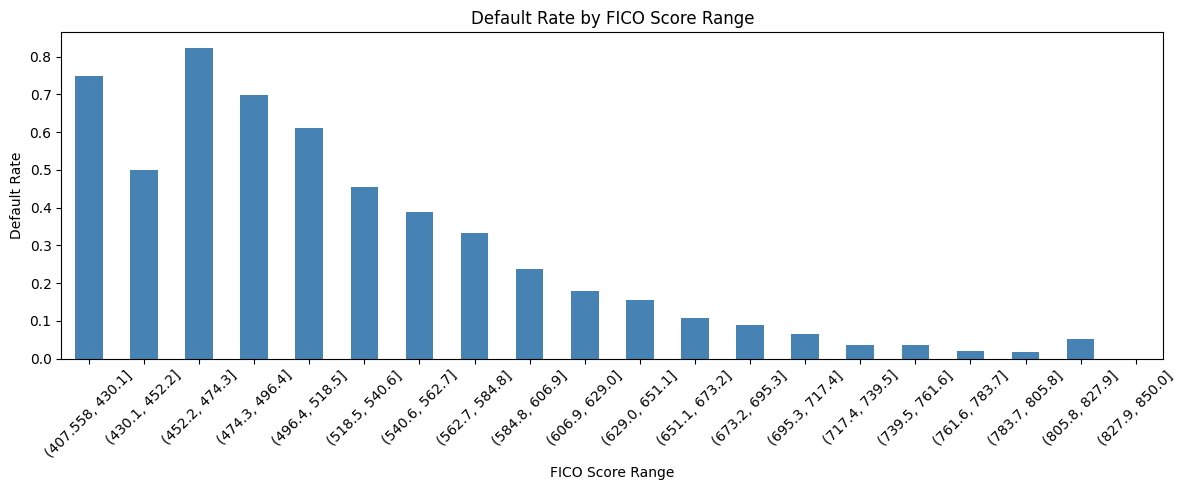

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Task 3 and 4_Loan_Data.csv')

# group FICO scores into 10-point intervals and calculate default rate
df['fico_bucket'] = pd.cut(df['fico_score'], bins=20)
default_by_fico = df.groupby('fico_bucket')['default'].mean()

plt.figure(figsize=(12, 5))
default_by_fico.plot(kind='bar', color='steelblue')
plt.title('Default Rate by FICO Score Range')
plt.xlabel('FICO Score Range')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:

def find_best_buckets(df, n_buckets=5):
    
    # sort by FICO score
    df_sorted = df[['fico_score', 'default']].sort_values('fico_score').reset_index(drop=True)
    
    # work with UNIQUE scores only — reduces from 10,000 rows to ~400 unique scores
    grouped   = df_sorted.groupby('fico_score')['default'].agg(['sum', 'count']).reset_index()
    scores    = grouped['fico_score'].values
    defaults  = grouped['sum'].values
    counts    = grouped['count'].values
    m         = len(scores)                    # ~400 instead of 10,000 — much faster!
    
    # cumulative sums for fast bucket calculations
    cum_k = np.concatenate([[0], np.cumsum(defaults)])
    cum_n = np.concatenate([[0], np.cumsum(counts)])
    
    def bucket_ll(i, j):
        """ log likelihood for bucket from index i to j """
        n = cum_n[j] - cum_n[i]
        k = cum_k[j] - cum_k[i]
        if n == 0 or k == 0 or k == n:
            return 0
        p = k / n
        return k * np.log(p) + (n - k) * np.log(1 - p)
    
    # dynamic programming table
    dp     = np.full((m + 1, n_buckets + 1), -np.inf)
    splits = np.zeros((m + 1, n_buckets + 1), dtype=int)
    dp[0][0] = 0
    
    for b in range(1, n_buckets + 1):
        for i in range(b, m + 1):
            for j in range(b - 1, i):
                score = dp[j][b-1] + bucket_ll(j, i)
                if score > dp[i][b]:
                    dp[i][b]     = score
                    splits[i][b] = j
    
    # traceback to find boundaries
    boundaries = []
    idx = m
    for b in range(n_buckets, 0, -1):
        split_idx = splits[idx][b]
        if split_idx > 0:
            boundaries.append(scores[split_idx])
        idx = split_idx
    
    boundaries = sorted(boundaries)
    boundaries = [int(scores.min())] + boundaries + [int(scores.max())]
    
    return boundaries

# run it
boundaries = find_best_buckets(df, n_buckets=5)
print('Best bucket boundaries:', boundaries)




Best bucket boundaries: [408, np.int64(521), np.int64(581), np.int64(641), np.int64(697), 850]


In [46]:
def assign_rating(fico_score, boundaries):
    """
    boundaries = [408, 521, 581, 641, 697, 850]
    lower rating = better credit = less likely to default
    """
    for i in range(len(boundaries) - 1):
        if fico_score <= boundaries[i + 1]:
            return i + 1       # rating 1 = best, 5 = worst
    return len(boundaries) - 1


# apply to every borrower
df['rating'] = df['fico_score'].apply(lambda x: assign_rating(x, boundaries))

# flip so lower rating = better (Rating 1 = safest)
df['rating'] = df['rating'].max() - df['rating'] + 1

print(df[['fico_score', 'rating', 'default']].head(10))

   fico_score  rating  default
0         605       3        0
1         572       4        1
2         602       3        0
3         612       3        0
4         631       3        0
5         697       2        0
6         722       1        0
7         545       4        1
8         676       2        0
9         447       5        0


In [47]:
# check default rate per rating — should go UP as rating number goes UP
summary = df.groupby('rating').agg(
    avg_fico    = ('fico_score', 'mean'),
    total       = ('default', 'count'),
    defaults    = ('default', 'sum'),
    default_rate = ('default', 'mean')
).round(3)

print(summary)


        avg_fico  total  defaults  default_rate
rating                                         
1        728.507   1602        76         0.047
2        667.471   3179       331         0.104
3        613.872   3458       699         0.202
4        558.466   1445       539         0.373
5        496.415    316       206         0.652


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# use rating as the only feature — that's the whole point of this task
X = df[['rating']]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_fico = LogisticRegression()
model_fico.fit(X_train, y_train)

print('Model trained!')

Model trained!


In [49]:
y_pred      = model_fico.predict(X_test)
y_pred_prob = model_fico.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC Score:', round(roc_auc_score(y_test, y_pred_prob), 4))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1652
           1       0.67      0.12      0.20       348

    accuracy                           0.84      2000
   macro avg       0.76      0.55      0.55      2000
weighted avg       0.81      0.84      0.79      2000

ROC-AUC Score: 0.7205


In [52]:
def expected_loss_fico(fico_score, loan_amount, recovery_rate=0.10):
    """
    fico_score    : borrower's FICO score
    loan_amount   : how much they borrowed
    recovery_rate : how much bank recovers on default (default 10%)
    """
    # step 1 — convert FICO score to rating
    rating = assign_rating(fico_score, boundaries)
    rating = df['rating'].max() - rating + 1

    # step 2 — predict probability of default
    pd_prob = model_fico.predict_proba(pd.DataFrame([[rating]], columns=['rating']))[0][1]


    # step 3 — calculate expected loss
    loss = loan_amount * pd_prob * (1 - recovery_rate)

    print(f"FICO Score             : {fico_score}")
    print(f"Rating                 : {rating}")
    print(f"Probability of Default : {pd_prob:.4f} ({pd_prob*100:.1f}%)")
    print(f"Loan Amount            : ${loan_amount:,.2f}")
    print(f"Expected Loss          : ${loss:,.2f}")

    return loss

In [53]:
print("=== Borrower 1 (High FICO) ===")
expected_loss_fico(fico_score=780, loan_amount=50000)

print("\n=== Borrower 2 (Medium FICO) ===")
expected_loss_fico(fico_score=620, loan_amount=50000)

print("\n=== Borrower 3 (Low FICO) ===")
expected_loss_fico(fico_score=480, loan_amount=50000)

=== Borrower 1 (High FICO) ===
FICO Score             : 780
Rating                 : 1
Probability of Default : 0.0462 (4.6%)
Loan Amount            : $50,000.00
Expected Loss          : $2,076.78

=== Borrower 2 (Medium FICO) ===
FICO Score             : 620
Rating                 : 3
Probability of Default : 0.2112 (21.1%)
Loan Amount            : $50,000.00
Expected Loss          : $9,505.33

=== Borrower 3 (Low FICO) ===
FICO Score             : 480
Rating                 : 5
Probability of Default : 0.5971 (59.7%)
Loan Amount            : $50,000.00
Expected Loss          : $26,870.98


np.float64(26870.978592894255)